In [1]:
## SAVING FILES EXMAPLE

# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

DOWNLOAD:

- results/
- downloads/data/filtered/final_aggregated/monthly_rows_with_missing_values.csv
- downloads/data/filtered/final_aggregated/final_model_training_data_2019.parquet

# Prior work insights:

Lei's:
- Goal: Predict edge based on Topological features only (excluding any geographical i.e. spatial and temporal information)
- Prediction Task: Monthly edge removal prediction (supervised binary classification defined as link prediction)
- Class imbalance strategy: random undersampling
- Dynamic network
- Brute force grid search 
- Models: XGBoost best (27 models evaluated)
- Lei's trained on non simultaneous (same time), to predict on same time, simultaneous trained on network on specific time (partially) to predict the remaining part. 
- Conclusion: Showed it's possible to do edge classification (link prediction) based on (local) topological features for fast changing networks
- Future work: suggests adding to their limited feature set in various ways
- My critique/takeaway: Monthly timeline

Merel's: 
- Goal: Attempted generalizability of Lei's work to edge classification and slower changing network 
- Prediction Task: Monthly binary edge classification of 'significantly' DELAYED trajectory (supervised binary classification as edge classification)
- Class imbalance strategy: Reclassification ground truth label per trajectory (aggregated trajectory) based on entire data distribution
- Excluded weights due to leakage; compensated by adding node measurements to capture station importance instead
- Static network -> assumed due to slow changing nature 
- RandomSearchCV 
- Models: LR,RF,DT,GB,AdaBoost,XGBoost
- Conclusion: Topology features showed limited performance
- Future work: suggested to include temporal, operational and environmental data, data limitation of monthly aggregation, ensemble models
- My critique/takeaway: Monthly timeline, data (station) aggregation strategy, class imbalance strategy unsuitable, static network representation, weights were most important feature in Lei's work

Brent's:
- Goal: integrate spatial temporal features into dynamic graph based models + temporal component on daily time scale trajectory DISRUPTIONS
- Prediction Task: Daily binary edge classification of CANCELLED trajectories 
- Class imbalance strategy: tree based models scale_pos_weight, DGNN = class weighted entropy loss, SMOTE rejected due to unsuitability
- Dynamic network 
- RandomSearchCV
- Models: LR, RF, GB, XGB, DGNN (proposed)
- Conclusion: Complexity of DGNN limited performance increase, bad absolute performance, weather features not relevant, feature selection issues (LSTM permutation importance)
- Future Work: Higher resolution meteorology data, feature selection methods for sequence and graph models (to increase XAI), full scale tests with external data
- My critique/takeaways: Weather dataset quality issues, limited performance increase vs huge complexity (computation and interpretability tradeoff), XGBoost similar so back to 

Ours: 
- Goal: Reevaluate Lei's generalizability of topological features for edge classification and evaluate operational (lag and preplanned schedule information) features, environmental features for tree based models.
- Prediction task: Hourly binary edge classification of DELAYED trajectories (i.e. predicting network state; will a trajectory be delayed or not (binary), for short term delay management)
- Class imbalance strategy: classification label definition (>0min passenger experience perpective), and tree based models scale_pos_weight
- Dynamic network, due to hourly granularity
- Hyperparameter: RandomSearchCV full dataset
- Models: LR, XGB, HistBoost (LGBM)
- Conclusion: TBD, limitations
- Future work: TBD, limitations
- Motivation for work to tackle LIMITATIONS of prior work I propose: Hourly (Merel data limitation), Stop level trajectory aggregation (Merel data limitation), Redefined classification label (Merel imbalance strategy), back to tree based models (Brent's increased complexity but limited performance increase compared to XGB in most settings), higher resolution of meteorology data (Brent's weather data limitation)


# Classification models notebook

## Imports

In [2]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================
# Import all necessary libraries for model training, evaluation, and visualization

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import torch
import matplotlib.pyplot as plt

import duckdb
######################

import sys
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,balanced_accuracy_score, mean_squared_error,r2_score,mean_absolute_error

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os
import joblib 
from tqdm import tqdm

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import learning_curve
from lightgbm import LGBMClassifier

# --- Preprocessing & Tuning ---
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline 
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score

import shap
from sklearn.impute import SimpleImputer 

import gc

import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

# 1. Silence Scikit-Learn and Python warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 2. Silence LightGBM's specific C++ backend warnings
import os
os.environ['LGBM_WARNING'] = '0'

# 3. Configure your Python logger to only show critical issues, not standard info/warnings
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)
logging.getLogger("xgboost").setLevel(logging.ERROR)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\ipykernel\ker

In [3]:
import sys
import random
import datetime
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

from datetime import date
from tqdm import tqdm
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

In [4]:
import sys
import random
import logging
import numpy as np
import pandas as pd
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score


## Globals

In [ ]:
# GLOBALS
# Set true for snellius job
snellius = True # Set True for snellius, False for local development
shap_analysis = False 

run_baseline = True # set true to run baseline tests (lei's trajectory slice)
check_randomcv = False

# LOCAL TESTING, SET FALSE
shap_sample = False # testing, but doesnt seem to be the bottle neck with baseline 
subset_dataset = False # True for quick small subset testing

TRAINING_FROM_YEAR = 2019
search_param = False

# Misc
partition = "services_full" if snellius else "services_subset"
PARAMETERS_FILENAME = "HPARAM" if search_param else "DEFAULT"
FILENAME_PARTITION = "SUBSET" if subset_dataset else "FULL"
# FILENAME_PARTITION = "test" if subset_dataset else "test_subset"
FILENAME_INFO = f"{PARAMETERS_FILENAME}_{FILENAME_PARTITION}_{TRAINING_FROM_YEAR}"

xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

RANDOM_SEED = 88 # For reproducibility
run_analysis = False #old hourly remove/adjust later

In [6]:
# KEY POINT: These are NOT time series sequences. Instead:
# - Each row represents ONE TRAJECTORY on ONE HOUR ON A SPECIFIC DATE
import os
from pathlib import Path

if snellius is False:
    # Change later to snellius $HOME or whatever folder you want to work in
    target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

    # Check if it exists before moving
    if target_root.exists():
        os.chdir(target_root)
        print(f"✅ Success! Moved to: {Path.cwd()}")
    else:
        print(f"❌ Error: The folder '{target_root}' does not exist.")

✅ Success! Moved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao


In [7]:
if snellius is True:
    # Get the home directory path object
    home_dir = Path.home() 

    # Build a path to your code
    target_root = home_dir / "NS_Thesis"

    print(target_root)

## File paths

In [8]:
project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
final_data_filepath = final_data_root / "final_dataset_with_operational.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"

results_xgb = results_folder / "results_XGB_naive"

results_xgb.mkdir(parents=True, exist_ok=True)

## Connect duckDB database

In [9]:
## Connect to database
db_name = f"{FILENAME_INFO}_main_classifications.duckdb"

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database=db_name) 

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
    con.execute("SET memory_limit='5GB'")   

Does file exist? True


In [10]:
con.execute(f"""
    CREATE OR REPLACE VIEW services_final AS 
    FROM read_parquet('{final_data_filepath}')""") 

## Feature lists

### FILTERED
src.degree              AS src_degree, # rides planned (to arrive)
src.weighted_degree     AS src_weighted_degree, # Total rides planned (inbound and outbound), brent only inbound
src.avg_distance        AS src_avg_distance, # Weighted average distance of rides planned in and outbound neighbours, brent only inbound

# Full feature set

In [11]:
#consistent with prior
topology_features = [
    'src_degree', # number of connections
    'tgt_degree', # number of connections
    'src_avg_distance_in', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment',
    'adamic_adar_index', 'resource_allocation_index',
    'src_avg_distance_out', 'src_avg_distance_total',
    'tgt_avg_distance_in', 'tgt_avg_distance_out',
    'tgt_avg_distance_total',
]

# Weight features
topology_weight_feature = [
    'decayed_edge_weight', 
    'src_w_deg_inbound', 'src_w_deg_outbound', 'src_w_deg_total',
    'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
]

weather_features = [
    'src_avg_temperature_2m', 'src_avg_rain', 'src_avg_snowfall',
    'src_avg_snow_depth', 'src_avg_wind_speed_10m',
    'src_avg_wind_gusts_10m', 'src_avg_soil_temperature',
    'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
    'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
    'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
]


# operational feature engineering, define in paper
operational_features = [
    'distance',
    'last_active_volume', 
    'months_since_last_service', 
    'is_new_or_stale_route',
    'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
    'ratio_operational_exceptions', 'ratio_sprinter',
]


cyclical_features = [
    # 'season_ordinal', 'month_sin', 'month_cos'
]

calendar_features = cyclical_features + [
# 'total_holidays',
# 'holiday_density_ratio', 'weekend_days', 'working_days',
# 'month',
]

# From historical service, not engineered
service_features = [
    'source', 'target', 'distance', 'year', 'month'
]

non_numeric_features = [
    'source', 'target', 'YearMonth', 'last_active_month',
]

all_num_features = topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# all_features = service_features + topology_features + topology_weight_feature + weather_features + calendar_features + operational_features

# multiclass dropped for now
target_features = ['target_absolute']

# features unknown at prediction time and utilized to calculate operational lag features and redundant 
features_to_drop = [
    'total_departure_delay_minutes', 'avg_departure_delay_minutes',
    'count_delayed_departure_services', 'total_delay_minutes',
    'avg_delay_minutes', 'count_delayed_services', 'total_services',
    'ratio_departure_delayed', 'ratio_arrival_delayed',
    'count_platform_changes', 'train_type_counts',
    'global_median', 'target_absolute', 'raw_intercity',
    'raw_intercity_direct', 'raw_international', 'raw_exceptions',
    # topology redundant
    # 'src_avg_distance_out',
    # 'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
    # 'tgt_avg_distance_in', 'tgt_avg_distance_out',
    # 'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
    # 'tgt_degree',
    # 'tgt_avg_distance_total', 
    # weather redundant
    # 'tgt_avg_temperature_2m', 'tgt_avg_rain', 'tgt_avg_snowfall',
    # 'tgt_avg_snow_depth', 'tgt_avg_wind_speed_10m',
    # 'tgt_avg_wind_gusts_10m', 'tgt_avg_soil_temperature',
    # cal redundant
    # 'month',
    # operational redundant
    # 'ratio_intercity', 'ratio_intercity_direct', 'ratio_international',
    # 'ratio_operational_exceptions', 'ratio_sprinter',
]

initial_cols_to_drop = ['train_type_counts', 'last_active_month']

In [12]:
len(all_num_features)

43

In [13]:
dataset_df = pd.read_parquet(final_data_filepath).drop(columns=initial_cols_to_drop)
dataset_df.columns

Index(['source', 'target', 'YearMonth', 'year', 'month', 'distance',
       'total_departure_delay_minutes', 'avg_departure_delay_minutes',
       'count_delayed_departure_services', 'total_delay_minutes',
       'avg_delay_minutes', 'count_delayed_services',
       'count_delayed_services_3min', 'total_services',
       'monthly_true_total_services', 'monthly_pure_delay_count',
       'monthly_cancellation_count', 'ratio_departure_delayed',
       'ratio_arrival_delayed', 'ratio_arrival_delayed_3min',
       'count_platform_changes', 'last_active_volume',
       'months_since_last_service', 'decayed_edge_weight',
       'is_new_or_stale_route', 'src_degree', 'src_w_deg_inbound',
       'src_w_deg_outbound', 'src_w_deg_total', 'src_avg_distance_total',
       'src_avg_distance_in', 'src_avg_distance_out', 'tgt_degree',
       'tgt_avg_distance_total', 'tgt_avg_distance_in', 'tgt_avg_distance_out',
       'tgt_w_deg_inbound', 'tgt_w_deg_outbound', 'tgt_w_deg_total',
       'common_neigh

In [14]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49790 entries, 0 to 49789
Data columns (total 81 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49790 non-null  object 
 1   target                            49790 non-null  object 
 2   YearMonth                         49790 non-null  object 
 3   year                              49790 non-null  int64  
 4   month                             49790 non-null  int64  
 5   distance                          49790 non-null  int32  
 6   total_departure_delay_minutes     49790 non-null  float64
 7   avg_departure_delay_minutes       49790 non-null  float64
 8   count_delayed_departure_services  49790 non-null  int64  
 9   total_delay_minutes               49790 non-null  float64
 10  avg_delay_minutes                 49790 non-null  float64
 11  count_delayed_services            49790 non-null  int64  
 12  coun

In [15]:
con.execute("DROP VIEW IF EXISTS services_final")

In [16]:
# Convert your list into a comma-separated string for the SQL query
refined_drop_list = list(set(features_to_drop) - {'YearMonth'})
cols_to_exclude = ", ".join(refined_drop_list)


In [17]:
con.execute(f"""
    CREATE OR REPLACE VIEW services_final AS 
    SELECT * EXCLUDE ({cols_to_exclude})
    FROM read_parquet('{final_data_filepath}') 
    ORDER BY year ASC, month ASC
""")

In [18]:
con.execute("""DESCRIBE services_final""").df()

,column_name,column_type,null,key,default,extra
0,source,VARCHAR,YES,None,None,None
1,target,VARCHAR,YES,None,None,None
2,YearMonth,VARCHAR,YES,None,None,None
3,year,BIGINT,YES,None,None,None
4,month,BIGINT,YES,None,None,None
...,...,...,...,...,...,...
61,ratio_operational_exceptions,FLOAT,YES,None,None,None
62,ratio_sprinter,FLOAT,YES,None,None,None
63,season_ordinal,INTEGER,YES,None,None,None
64,month_sin,DOUBLE,YES,None,None,None


## Stations

Inclusion of ALL trains with NS label as company (Intercity, Sprinter etc.) + filtering down to NL stations resulted in 307 stations in the final services dataset

In [19]:
if run_analysis:
    # Query to get the total count of unique stations
    unique_stations_count = con.execute("""
        SELECT count(DISTINCT station) 
        FROM (
            SELECT source AS station FROM services_final
            UNION 
            SELECT target AS station FROM services_final
        )
    """).fetchone()[0]

    print(f"Total unique stations: {unique_stations_count}")

# Dataset utilized

## Remaining NA values in pandas

last_active_month = NA represent the edges in the first month in our dataset -> should have 0 NA values now

In [20]:
# --- NEW: Calculate and print missing % per column ---
total_rows = len(dataset_df)
missing_per_column = dataset_df.isna().sum()

# Filter to only show columns that actually have missing values
missing_columns_only = missing_per_column[missing_per_column > 0]

if not missing_columns_only.empty:
    print("\n[!] Breakdown of missing values per column:")
    
    # Loop through and print the count and percentage for each column
    for col, count in missing_columns_only.items():
        pct = (count / total_rows) * 100
        print(f"    - {col}: {count} missing ({pct:.2f}%)")
else:
    print("\n[OK] No missing values found in any columns.")

# 1. Identify rows with ANY missing values
rows_with_missing = dataset_df[dataset_df.isna().any(axis=1)]

if not rows_with_missing.empty:
    missing_count = len(rows_with_missing)
    missing_percentage = (missing_count / total_rows) * 100
    
    # --- SAVE TO PARQUET ---
    missing_filename = f"monthly_rows_with_missing_values.csv"
    missing_filename_path = final_data_root / missing_filename
    
    rows_with_missing.to_csv(missing_filename_path)
    
    print(f"\n[!] Dropping {missing_count} rows containing missing data ({missing_percentage:.2f}% of total).")
    print(f"    Saved these rows to: {missing_filename_path}")

# --- DROP FROM MAIN DATAFRAME ---
dataset_cleaned_df = dataset_df.dropna()


[OK] No missing values found in any columns.


# Final dataset for training

In [21]:
final_dataset_for_training_name = f"final_model_training_data_{TRAINING_FROM_YEAR}.parquet"
final_dataset_for_training_path = final_data_root / final_dataset_for_training_name
dataset_cleaned_df.to_parquet(final_dataset_for_training_path)
print(f"    Remaining rows: {len(dataset_cleaned_df)}")

    Remaining rows: 49790


Doublecheck

In [22]:
# Identify columns with missing values
missing_counts = dataset_cleaned_df.isna().sum()
null_columns = missing_counts[missing_counts > 0]
if not null_columns.empty:
    print("\nColumns with missing values:")
    print(null_columns)
else:
    print("\nNo missing values found in any columns.")


No missing values found in any columns.


In [23]:
dataset_cleaned_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49790 entries, 0 to 49789
Data columns (total 81 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49790 non-null  object 
 1   target                            49790 non-null  object 
 2   YearMonth                         49790 non-null  object 
 3   year                              49790 non-null  int64  
 4   month                             49790 non-null  int64  
 5   distance                          49790 non-null  int32  
 6   total_departure_delay_minutes     49790 non-null  float64
 7   avg_departure_delay_minutes       49790 non-null  float64
 8   count_delayed_departure_services  49790 non-null  int64  
 9   total_delay_minutes               49790 non-null  float64
 10  avg_delay_minutes                 49790 non-null  float64
 11  count_delayed_services            49790 non-null  int64  
 12  coun

In [24]:
# Calculate total bytes
total_bytes = dataset_cleaned_df.memory_usage(deep=True).sum()

# Convert to GB
print(f"Total Memory Usage: {total_bytes / (1024 ** 3):.2f} GB")

Total Memory Usage: 0.03 GB


In [25]:
dataset_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49790 entries, 0 to 49789
Data columns (total 81 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   source                            49790 non-null  object 
 1   target                            49790 non-null  object 
 2   YearMonth                         49790 non-null  object 
 3   year                              49790 non-null  int64  
 4   month                             49790 non-null  int64  
 5   distance                          49790 non-null  int32  
 6   total_departure_delay_minutes     49790 non-null  float64
 7   avg_departure_delay_minutes       49790 non-null  float64
 8   count_delayed_departure_services  49790 non-null  int64  
 9   total_delay_minutes               49790 non-null  float64
 10  avg_delay_minutes                 49790 non-null  float64
 11  count_delayed_services            49790 non-null  int64  
 12  coun

In [26]:
dataset_cleaned_df['target_absolute']

0        0
1        1
2        1
3        1
4        0
        ..
49785    0
49786    1
49787    1
49788    0
49789    1
Name: target_absolute, Length: 49790, dtype: int32

# Class balance

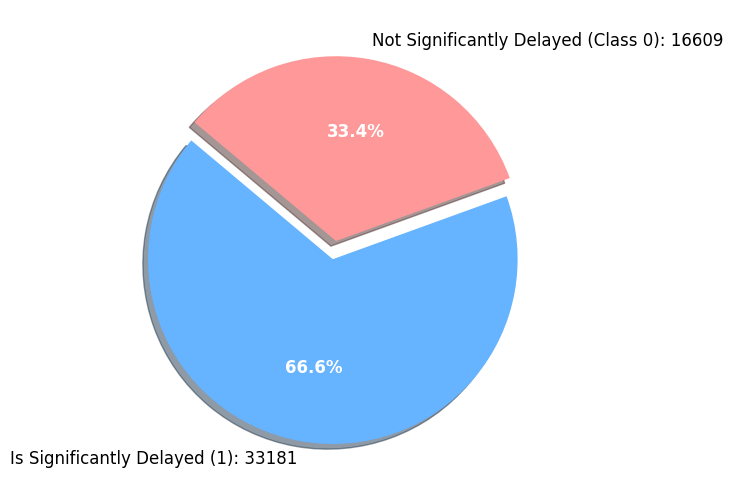

Negative Count: 16609
Positive Count: 33181
Class balance: 0.5005575479943342
Recommended scale_pos_weight: 0.50


In [27]:
# 2. Extract counts (0 is Negative, 1 is Positive)
neg_count = dataset_cleaned_df[dataset_cleaned_df['target_binary'] == 0].shape[0]
pos_count = dataset_cleaned_df[dataset_cleaned_df['target_binary'] == 1].shape[0]

# Calculate percentages
total_count = neg_count + pos_count
neg_pct = (neg_count / total_count) * 100
pos_pct = (pos_count / total_count) * 100


# 1. Calculate counts and percentages
counts = dataset_cleaned_df['target_binary'].value_counts()
total = counts.sum()

# Create labels that include the raw count: e.g., "On-Time (0): 950"
labels = [f'{ "Not Significantly Delayed (Class 0)" if x == 0 else "Is Significantly Delayed (1)" }: {counts[x]}' for x in counts.index]
colors = ['#66b3ff', '#ff9999']

# 2. Plotting
plt.figure(figsize=(8, 6))
patches, texts, autotexts = plt.pie(
    counts, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    shadow=True, 
    startangle=140, 
    explode=(0.1, 0) if len(counts) > 1 else None,
    textprops={'fontsize': 12}
)

# Style the percentage text inside the pie to be bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

save_dir = Path(media_folder) / "EDA"

save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(save_dir / 'class_balance.png', bbox_inches='tight', dpi=300)
plt.show()


# 3. Store the ratio
# scale_pos_weight acts as a multiplier for the positive class gradient
if pos_count > 0:
    scale_pos_weight_value_train = neg_count / pos_count
else:
    scale_pos_weight_value_train = 1.0  # Fallback to neutral weight
    print("Warning: No positive instances found!")

print(f"Negative Count: {neg_count}")
print(f"Positive Count: {pos_count}")
print(f"Class balance: {neg_count / pos_count}")
print(f"Recommended scale_pos_weight: {scale_pos_weight_value_train:.2f}")

# Prep Data (subset/fulll)

In [28]:
# 1. Load the full dataset
df = pd.read_parquet(final_dataset_for_training_path)
if subset_dataset:
    data_df = df[(df['year'] >= 2024) & (df['month'] < 12)].copy()
    print(f"✅ Subset loaded. Rows: {len(data_df)}")
    print(f"Unique Years: {data_df['year'].unique()} | Unique Months: {data_df['month'].unique()}")
else:
    data_df = df.copy()
    print(f"✅ Full data loaded. Rows: {len(data_df)}")
    print(f"Unique Years: {data_df['year'].unique()} | Unique Months: {data_df['month'].unique()}")

✅ Full data loaded. Rows: 49790
Unique Years: [2019 2022 2020 2021 2023 2024] | Unique Months: [ 6  3  7  1 10  5 11  8 12  2  9  4]


# 1_Class_Base ADAPTED

In [30]:
# if run_baseline:
#     import sys
#     import random
#     import datetime
#     import shap

#     import pandas as pd
#     import numpy as np
#     import matplotlib.pyplot as plt
#     import seaborn as sns
#     import scipy.stats as ss

#     from datetime import date
#     from tqdm import tqdm
#     from imblearn.under_sampling import RandomUnderSampler
#     from xgboost import XGBClassifier
#     from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

#     sys.path.append('src')
#     # from plot_style import *

#     def get_trajectory_slice(data, f_train_e=0.7, seed=RANDOM_SEED):
#         df = data
#         trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
#         random.seed(seed)
#         train_size = int(f_train_e * len(trajectories))
#         random.shuffle(trajectories)
#         train_trajectories = set(trajectories[:train_size])
#         test_trajectories = set(trajectories[train_size:])
        
#         df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
#         df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
        
#         return df_train, df_test

#     def df_to_XY(df, features, target='target_absolute'):
#         X = df.loc[:, features].to_numpy()
#         y = df.loc[:, target].to_numpy()
#         return X, y

#     def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#         if name is None:
#             name = ''.join([w[0] for w in features]) + '_simultaneous'
#         else:
#             name = name + '_simultaneous'
        
#         year_month_list = sorted(df_train['YearMonth'].unique())
#         res_df_test = df_test.copy()
#         res_df_test['simultaneous_pred'] = np.nan
#         res_df_test['simultaneous_null'] = np.nan
        
#         for year_month in tqdm(year_month_list):
#             X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#             ros = RandomUnderSampler()
#             X_train, y_train = ros.fit_resample(X_train, y_train)
#             X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
            
#             y_train_null = y_train.copy()
#             np.random.shuffle(y_train_null)
            
#             model = XGBClassifier(**best_params)
#             model.fit(X_train, y_train)
#             model_null = XGBClassifier(**best_params)
#             model_null.fit(X_train, y_train_null)
            
#             y_pred = model.predict(X_test)
#             y_pred_null = model_null.predict(X_test)
            
#             res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
#             res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
        
#         if save:
#             res_df_test.to_csv(f'{results_xgb}/{name}.csv', index=False)
        
#         return res_df_test

#     def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#         if name is None:
#             name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
#         else:
#             name = name + '_nonsimultaneous'
        
#         year_month_list = sorted(df_test['YearMonth'].unique())
#         preds = []
        
#         for year_month_train in tqdm(year_month_list):
#             X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
#             ros = RandomUnderSampler()
#             X_train, y_train = ros.fit_resample(X_train, y_train)
            
#             y_train_null = y_train.copy()
#             np.random.shuffle(y_train_null)
            
#             model = XGBClassifier(**best_params)
#             model.fit(X_train, y_train)
#             model_null = XGBClassifier(**best_params)
#             model_null.fit(X_train, y_train_null)
            
#             for year_month_test in year_month_list:
#                 if year_month_test < year_month_train:
#                     continue
#                 X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
#                 y_pred = model.predict(X_test)
#                 y_null = model_null.predict(X_test)
#                 preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
        
#         if save:
#             import pickle
#             with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
#                 pickle.dump(preds, f)
        
#         return preds

#     # Migrate into nonsim testing?, plot_shap_values, shap on train set
#     def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
#         if name is None:
#             name = ''.join([w[0] for w in features]) + '_SHAP'
#         else:
#             name = name + '_SHAP'
#         # 1. Define the save directory and create it if it doesn't exist
#         save_dir = f"{results_xgb}/SHAP_plots/{name}"
#         os.makedirs(save_dir, exist_ok=True)

#         #unused
#         def get_temporal_order(shap_list):
#             importance_array = []
#             for shap_values in shap_list:
#                 array = -np.abs(shap_values).mean(axis=0)
#                 ranks = ss.rankdata(array)
#                 importance_array.append(ranks)
#             return np.array(importance_array)

#         shap_values_list = []
#         test_list = []
#         year_month_list = sorted(df_test['YearMonth'].unique())
        
#         for year_month in tqdm(year_month_list):
#             X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#             ros = RandomUnderSampler()
#             X_train, y_train = ros.fit_resample(X_train, y_train)
#             X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
            
#             # FULL MODEL
#             model = XGBClassifier(**best_params)
#             model.fit(X_train, y_train)

#             # -------------SHAP EXPLANATAIONS-------------------
#             # Utilizing shap easier new api explainer object
#             if not isinstance(X_test, pd.DataFrame):
#                 X_test_shap = pd.DataFrame(X_test, columns=features)

#             # SAMPLING FOR SHAP (brents)
#             if shap_sample:
#                 X_test_shap = X_test_shap.sample(n=min(1000, len(X_test)), random_state=RANDOM_SEED)
                
#             clean_year_month = year_month.strftime('%Y-%m')

#             explainer = shap.TreeExplainer(model)
#             shap_explanation = explainer(X_test_shap.values)
#             shap_values = shap_explanation.values
#             mean_abs_shap = shap_explanation.abs.mean(0).values

#             test_list.append(pd.DataFrame(X_test, columns=features))
#             shap_values_list.append(shap_values)

#             model_type = 'XGBoost'
#             threshold = 0.5
#             shap_df = pd.DataFrame({
#                 'feature': features, # Or whatever your DuckDB feature list variable is called
#                 'mean_shap': mean_abs_shap
#             })
#             try:
#                 # SHAP Summary Plot
#                 plt.figure()
#                 shap.summary_plot(shap_values, X_test_shap, feature_names=features, max_display=20, show=False)
#                 plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()} ({clean_year_month})")
#                 plt.tight_layout()
#                 summary_filename = f"{save_dir}/{clean_year_month}_{model_type}_{name}_summary.png"
#                 plt.savefig(summary_filename, dpi=300, bbox_inches='tight')
#                 # plt.show()
#                 plt.close()

#                 # Bar plot of mean SHAP values
#                 plt.figure(figsize=(10, 6))
#                 shap_df_sorted = shap_df.sort_values('mean_shap', ascending=False)
#                 plt.bar(shap_df_sorted['feature'], shap_df_sorted['mean_shap'])
#                 plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
#                 plt.xticks(rotation=45, ha='right')
#                 plt.xlabel('Features')
#                 plt.ylabel('Mean Absolute SHAP Value')
#                 plt.title(f"Mean Absolute SHAP Values for {model_type.replace('_', ' ').title()} ({clean_year_month})")
#                 plt.legend()
#                 plt.tight_layout()
#                 bar_filename = f"{save_dir}/{clean_year_month}_{model_type}_{name}_bar.png"
#                 plt.savefig(bar_filename, dpi=300, bbox_inches='tight')
#                 # plt.show()
#                 plt.close()
#             except Exception as e:
#                 # If anything goes wrong, catch the error, print it, and keep the loop alive
#                 print(f"⚠️ WARNING: Failed to generate SHAP plots for {clean_year_month}. Skipping visualization.")
#                 print(f"Error Details: {e}")
                
#                 plt.close('all')
        
#         if save:
#             import pickle
#             with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
#                 pickle.dump((test_list, year_month_list, shap_values_list), f)
        
#         return test_list, year_month_list, shap_values_list


#     def TOP(train, test):
#         name = 'NS_I_TOP'
#         features = topology_features
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     def WGT(train, test):
#         name = 'NS_I_WGT'
#         features = topology_weight_feature
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     def WTH(train, test):
#         name = 'NS_I_WTH'
#         features = weather_features
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     def OPS(train, test):
#         name = 'NS_I_OPS'
#         features = operational_features
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     # def CAL(train, test):
#     # 	name = 'NS_I_CAL'
#     # 	features = calendar_features
#     # 	simultaneous_test(train, test, features, best_params, name=name)
#     # 	nonsimultaneous_test(train, test, features, best_params, name=name)
#     # 	if shap_analysis:
#     # 		all_shap_values(train, test, features, best_params, name=name)

#     def TW(train, test):
#         name = 'NS_C_TW'
#         features = topology_features + topology_weight_feature
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     # def TWC(train, test):
#     # 	name = 'NS_C_TWC'
#     # 	features = topology_features + topology_weight_feature + calendar_features
#     # 	simultaneous_test(train, test, features, best_params, name=name)
#     # 	nonsimultaneous_test(train, test, features, best_params, name=name)
#     # 	if shap_analysis:
#     # 		all_shap_values(train, test, features, best_params, name=name)

#     def TWCW(train, test):
#         name = 'NS_C_TWCW'
#         features = topology_features + topology_weight_feature + calendar_features + weather_features
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     def TWCO(train, test):
#         name = 'NS_C_TWCO'
#         features = topology_features + topology_weight_feature + calendar_features + operational_features
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     def ALLF(train, test):
#         name = 'NS_C_ALLF'
#         features = topology_features + topology_weight_feature + calendar_features + operational_features + weather_features
#         simultaneous_test(train, test, features, best_params, name=name)
#         nonsimultaneous_test(train, test, features, best_params, name=name)
#         if shap_analysis:
#             all_shap_values(train, test, features, best_params, name=name)

#     if __name__ == "__main__":
#         global best_params
#         # best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#         # 			'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#         # 			'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}
#         best_params = {'objective': 'binary:logistic', 'booster': 'gbtree', 'random_state': RANDOM_SEED}

#         data = data_df
#         data['YearMonth'] = pd.to_datetime(data['YearMonth'])    
#         train, test = get_trajectory_slice(data)
#         # ## Individual sets
#         TOP(train, test)
#         WGT(train, test)
#         WTH(train, test)
#         OPS(train, test)
#         # CAL(train, test)

#         TW(train, test)

#         ## Combined
#         # TWC(train, test)
#         TWCW(train, test)
#         TWCO(train, test)
#         ALLF(train, test)

# Naive

In [31]:
if run_baseline:
    import sys
    import random
    import datetime
    import os
    import pickle
    import pandas as pd
    import numpy as np
    from tqdm import tqdm

    sys.path.append('src')

    def get_trajectory_slice(data, f_train_e=0.7, seed=RANDOM_SEED):
        df = data
        trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
        random.seed(seed)
        train_size = int(f_train_e * len(trajectories))
        random.shuffle(trajectories)
        train_trajectories = set(trajectories[:train_size])
        test_trajectories = set(trajectories[train_size:])
        
        df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
        df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
        
        return df_train, df_test

    def nonsimultaneous_test(df_train, df_test, features=None, best_params=None, save=True, name=None):
        if name is None:
            name = 'naive_nonsimultaneous'
        else:
            name = name + '_naive_nonsimultaneous'
        
        year_month_list = sorted(df_test['YearMonth'].unique())
        preds = []
        
        # Create a lookup dictionary for fast prior-month retrieval
        # Keys: (source, target, YearMonth timestamp) | Values: target_binary
        lookup = df_test.set_index(['source', 'target', 'YearMonth'])['target_binary'].to_dict()
        
        for year_month_train in tqdm(year_month_list):
            for year_month_test in year_month_list:
                if year_month_test < year_month_train:
                    continue
                
                # Extract the test slice for the current evaluation month
                test_slice = df_test[df_test['YearMonth'] == year_month_test]
                y_test = test_slice['target_binary'].to_numpy()
                
                # Determine the exact previous month mathematically
                prior_month = year_month_test - pd.DateOffset(months=1)
                
                # Generate naive predictions
                y_pred = []
                for _, row in test_slice.iterrows():
                    # Fetch the prior month's value, defaulting to 0.0 if trajectory didn't exist
                    val = lookup.get((row['source'], row['target'], prior_month), 0.0)
                    y_pred.append(val)
                
                y_pred = np.array(y_pred)
                
                # Use NaN array as a placeholder to maintain matching lengths for the pipeline
                y_null = np.full_like(y_test, np.nan, dtype=float)
                
                # Append to preds in the exact format required by the extraction pipeline
                preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
        
        if save:
            os.makedirs(results_xgb, exist_ok=True)
            with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
                pickle.dump(preds, f)
        
        return preds

    def ALLF(train, test):
        name = 'NS_C_ALLF'
        nonsimultaneous_test(train, test, name=name)

    if __name__ == "__main__":
        data = data_df
        data['YearMonth'] = pd.to_datetime(data['YearMonth'])    
        train, test = get_trajectory_slice(data)
        
        ALLF(train, test)

100%|██████████| 72/72 [00:26<00:00,  2.75it/s]


# Seasonal naive

In [32]:
results_xgb = results_folder / "results_XGB_Snaive"

results_xgb.mkdir(parents=True, exist_ok=True)

In [33]:
if run_baseline:
    import sys
    import random
    import datetime
    import os
    import pickle
    import pandas as pd
    import numpy as np
    from tqdm import tqdm

    sys.path.append('src')

    def get_trajectory_slice(data, f_train_e=0.7, seed=RANDOM_SEED):
        df = data
        trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
        random.seed(seed)
        train_size = int(f_train_e * len(trajectories))
        random.shuffle(trajectories)
        train_trajectories = set(trajectories[:train_size])
        test_trajectories = set(trajectories[train_size:])
        
        df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
        df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
        
        return df_train, df_test

    def nonsimultaneous_test(df_train, df_test, features=None, best_params=None, save=True, name=None):
        if name is None:
            name = 'Snaive_nonsimultaneous'
        else:
            name = name + '_Snaive_nonsimultaneous'
        
        year_month_list = sorted(df_test['YearMonth'].unique())
        preds = []
        
        # Create a lookup dictionary for fast prior-month retrieval
        # Keys: (source, target, YearMonth timestamp) | Values: target_binary
        lookup = df_test.set_index(['source', 'target', 'YearMonth'])['target_binary'].to_dict()
        
        for year_month_train in tqdm(year_month_list):
            for year_month_test in year_month_list:
                if year_month_test < year_month_train:
                    continue
                
                # Extract the test slice for the current evaluation month
                test_slice = df_test[df_test['YearMonth'] == year_month_test]
                y_test = test_slice['target_binary'].to_numpy()
                
                # Determine the exact previous month mathematically
                prior_month = year_month_test - pd.DateOffset(months=12)
                
                # Generate naive predictions
                y_pred = []
                for _, row in test_slice.iterrows():
                    # Fetch the prior month's value, defaulting to 0.0 if trajectory didn't exist
                    val = lookup.get((row['source'], row['target'], prior_month), 0.0)
                    y_pred.append(val)
                
                y_pred = np.array(y_pred)
                
                # Use NaN array as a placeholder to maintain matching lengths for the pipeline
                y_null = np.full_like(y_test, np.nan, dtype=float)
                
                # Append to preds in the exact format required by the extraction pipeline
                preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
        
        if save:
            os.makedirs(results_xgb, exist_ok=True)
            with open(f'{results_xgb}/{name}.pkl', 'wb') as f:
                pickle.dump(preds, f)
        
        return preds

    def ALLF(train, test):
        name = 'NS_C_ALLF'
        nonsimultaneous_test(train, test, name=name)

    if __name__ == "__main__":
        data = data_df
        data['YearMonth'] = pd.to_datetime(data['YearMonth'])    
        train, test = get_trajectory_slice(data)
        
        ALLF(train, test)

100%|██████████| 72/72 [00:27<00:00,  2.62it/s]
